## 🧠 EDA — Avis Google (Best Western)

Objectif : comprendre les avis (notes, longueur, contributions, hôtels) et repérer les profils potentiellement influents.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv(r"C:\Users\Wouaff\memoire-clients-influents\data\processed\avis_google_hotels.csv")
df.head()


,auteur,avis,contributions,hotel,nb_avis_total,note,note_moyenne
0,alexandre Morel,Hotel situé à 6 minutes de la gare montparnass...,62,BW_Bretagne,549,5.0,3.8
1,Marilyn Robin,"Cet hôtel est idéal, le personnel est à l'écou...",8,BW_Bretagne,549,5.0,3.8
2,Benjamin,"Hôtel parfait pour un week end à Paris, proche...",1,BW_Bretagne,549,5.0,3.8
3,Isabelle Besson 73,Nous avons passé 2 nuits en mai dans le Best W...,16,BW_Bretagne,549,5.0,3.8
4,jerome schenck,Je réserve très régulièrement des chambres d'h...,138,BW_Bretagne,549,5.0,3.8


## 🔍 1. Aperçu global des données

Nous vérifions la structure générale du dataset :
- Types de colonnes  
- Dimensions  
- Statistiques descriptives  
- Valeurs manquantes


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2763 entries, 0 to 2762
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   auteur         2763 non-null   object 
 1   avis           2152 non-null   object 
 2   contributions  2763 non-null   int64  
 3   hotel          2763 non-null   object 
 4   nb_avis_total  2763 non-null   int64  
 5   note           2752 non-null   float64
 6   note_moyenne   2763 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.2+ KB


auteur             0
avis             611
contributions      0
hotel              0
nb_avis_total      0
note              11
note_moyenne       0
dtype: int64

Le dataset comporte 2763 avis, dont 22% sans texte, mais les notes et contributions sont quasi complètes. La plupart des clients donnent des notes positives (~4/5), tandis qu’une minorité publie des avis longs et détaillés. L’analyse descriptive révèle donc deux profils distincts : la masse d’avis courts et neutres, et une minorité d’avis narratifs plus critiques.

## 📊 2 — Profils influents
- Qui sont les auteurs les plus actifs ?
- Quel est leur volume de contributions ?

Graphiques : **distribution des notes**, **top 10 des contributeurs**.


### Distribution des notes


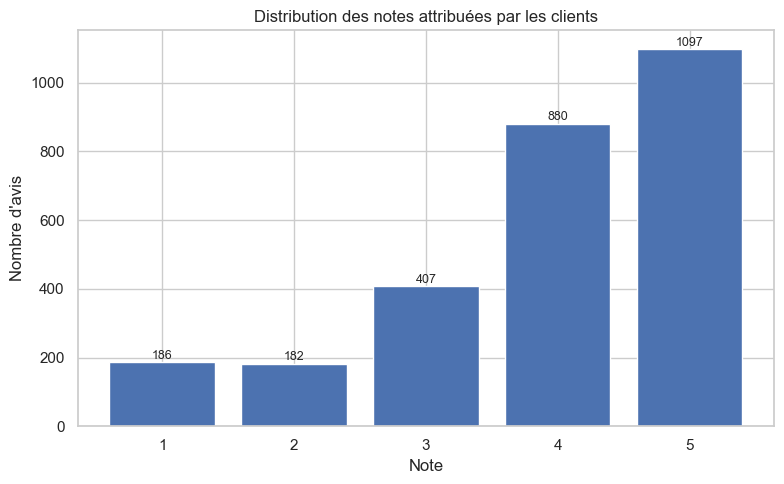

In [4]:
plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(
    df["note"], bins=range(1, 7), align="left", rwidth=0.8
)
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count + 1,
            int(count),
            ha="center", va="bottom", fontsize=9,
        )
plt.title("Distribution des notes attribuées par les clients")
plt.xlabel("Note")
plt.ylabel("Nombre d'avis")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()



La distribution des notes met en évidence une forte prédominance d’avis positifs (notes 4 et 5), alors que les avis faibles (1 et 2) sont marginaux. Toutefois, ces avis négatifs, bien que minoritaires, ont un impact symbolique disproportionné et peuvent peser davantage sur la perception globale, d’où l’importance d’identifier les auteurs qui les publient régulièrement.

### Top 10 des contributeurs


C:\Users\Wouaff\AppData\Local\Temp\ipykernel_1992\2258860262.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_contrib.values, y=top_contrib.index, palette="crest", ax=ax)
C:\Users\Wouaff\AppData\Local\Temp\ipykernel_1992\2258860262.py:13: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Wouaff\AppData\Local\Temp\ipykernel_1992\2258860262.py:13: UserWarning: Glyph 54812 (\N{HANGUL SYLLABLE HYE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\Wouaff\AppData\Local\Temp\ipykernel_1992\2258860262.py:13: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) Arial.
  fig.tight_layout()
c:\Users\Wouaff\memoire-clients-influents\env-2025\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from

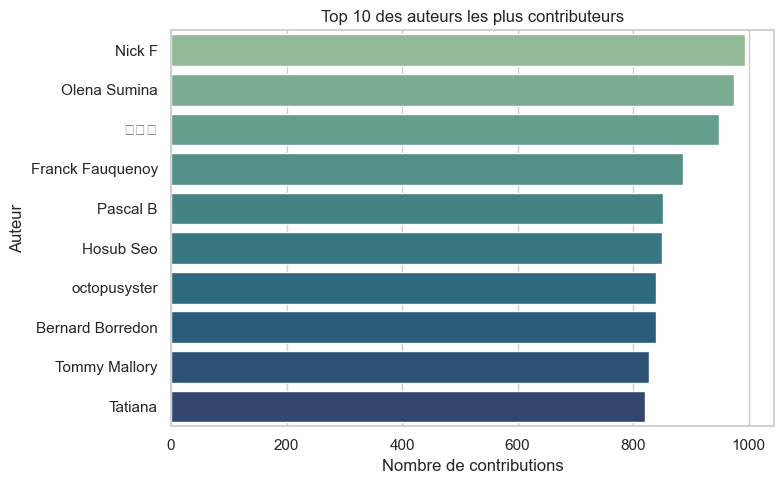

In [5]:
top_contrib = (
    df.groupby("auteur")["contributions"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=top_contrib.values, y=top_contrib.index, palette="crest", ax=ax)
ax.set_title("Top 10 des auteurs les plus contributeurs")
ax.set_xlabel("Nombre de contributions")
ax.set_ylabel("Auteur")
fig.tight_layout()
plt.show()


Le top 10 des contributeurs montre des profils extrêmement actifs, dépassant parfois les 900 contributions. Ces auteurs réguliers, par leur visibilité et leur constance, représentent des candidats privilégiés à l’influence, car leurs avis s’imposent dans le volume global et façonnent fortement la réputation des établissements.

## 📊 3 — Types d’avis
- Les avis sont-ils longs ? Positifs ? Négatifs ?
- **Histogramme du nombre de mots**
- **Distribution des notes (KDE)**


### Histogramme du nombre de mots


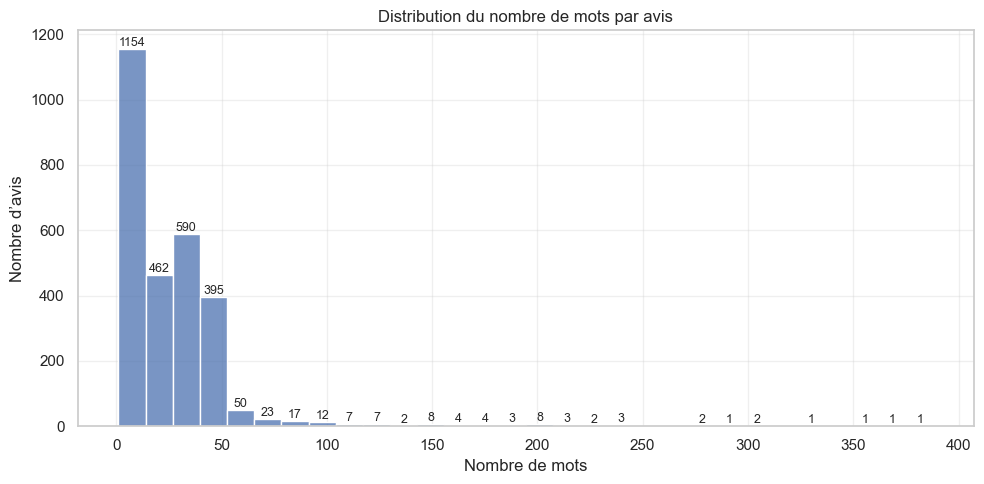

In [6]:
d = df.copy()
d["nb_mots_avis"] = d["avis"].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
ax = sns.histplot(d["nb_mots_avis"], bins=30, kde=False)
for p in ax.patches:
    h = int(p.get_height())
    if h > 0:
        ax.annotate(
            str(h),
            (p.get_x() + p.get_width() / 2., h),
            ha="center", va="bottom", fontsize=9
        )
plt.title("Distribution du nombre de mots par avis")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre d’avis")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


La distribution du nombre de mots montre que la majorité des avis sont très courts : plus de 70 % font moins de 50 mots. Les avis longs, bien que rares, sont souvent plus critiques et détaillés, ce qui leur confère un poids disproportionné dans la perception globale. Leur faible fréquence mais forte intensité en fait un levier essentiel pour identifier les clients potentiellement « influents », dont la rédaction structurée peut marquer durablement la réputation des hôtels.

### Distribution des notes (KDE)


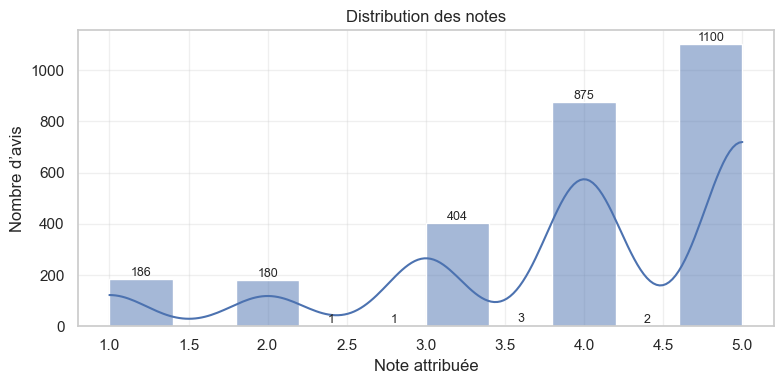

In [7]:
plt.figure(figsize=(8, 4))
ax = sns.histplot(df["note"], bins=10, kde=True)
for bar in ax.patches:
    val = int(bar.get_height())
    if val > 0:
        ax.annotate(
            str(val),
            (bar.get_x() + bar.get_width() / 2., val),
            ha="center", va="bottom", fontsize=9
        )
plt.title("Distribution des notes")
plt.xlabel("Note attribuée")
plt.ylabel("Nombre d’avis")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


La distribution des notes confirme une nette dominance des avis positifs : près des trois quarts se situent sur les scores 4 et 5. Les notes basses (1 et 2), bien que minoritaires, structurent toutefois des pics visibles qui traduisent des expériences marquées. Cette polarisation illustre un double enjeu : la majorité reflète une satisfaction globale élevée, tandis que les avis négatifs, plus rares, contribuent fortement à façonner la perception des établissements.

## 📊 4 — Analyse par hôtel
- Quels hôtels reçoivent le plus d’avis ?
- Certains hôtels sont-ils mieux notés ?
- Hypothèse de **polarisation** : beaucoup d’avis mais note plus basse.


### Nombre d’avis par hôtel


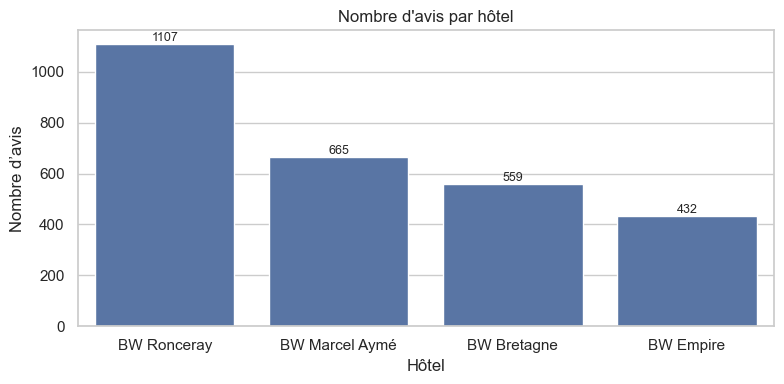

In [8]:
df_plot = df.copy()
df_plot["hotel"] = df_plot["hotel"].replace({
    "BW_Empire_Elysees": "BW Empire",
    "BW_Bretagne": "BW Bretagne",
    "BW_Ronceray_Opera": "BW Ronceray",
    "BW_Litteraire_Marcel_Ayme": "BW Marcel Aymé",
})

plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=df_plot,
    x="hotel",
    order=df_plot["hotel"].value_counts().index
)
for bar in ax.patches:
    v = int(bar.get_height())
    ax.annotate(str(v),
                (bar.get_x() + bar.get_width()/2., v),
                ha="center", va="bottom", fontsize=9)
plt.title("Nombre d'avis par hôtel")
plt.xlabel("Hôtel")
plt.ylabel("Nombre d’avis")
plt.tight_layout()
plt.show()


Le BW Ronceray concentre plus de 1 100 avis, soit nettement plus que les autres hôtels. À l’inverse, le BW Empire reste le moins commenté avec environ 430 avis. Cette disparité révèle une exposition très inégale : certains établissements génèrent beaucoup plus de visibilité, ce qui accroît la probabilité d’y trouver des clients centraux. Toutefois, un volume élevé d’avis n’implique pas forcément une meilleure réputation : la question sera de savoir si cette surreprésentation rime avec une perception positive ou au contraire polarisée.

### Note moyenne officielle (Google) par hôtel


C:\Users\Wouaff\AppData\Local\Temp\ipykernel_1992\3320741503.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=moy.index, y=moy.values, palette="crest")


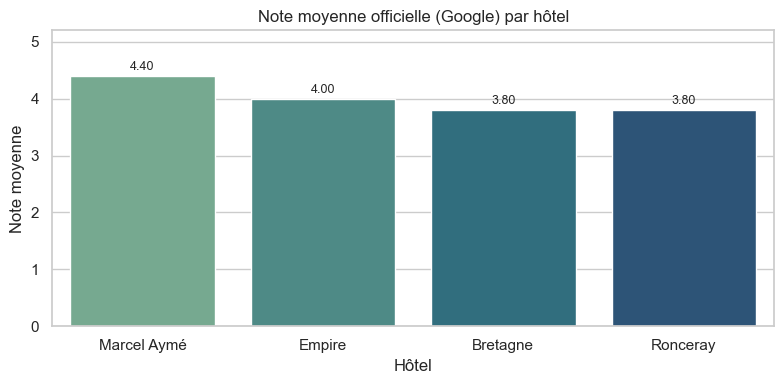

In [9]:
df_plot = df.copy()
df_plot["hotel"] = df_plot["hotel"].replace({
    "BW_Empire_Elysees": "Empire",
    "BW_Bretagne": "Bretagne",
    "BW_Ronceray_Opera": "Ronceray",
    "BW_Litteraire_Marcel_Ayme": "Marcel Aymé",
})
moy = df_plot.groupby("hotel")["note_moyenne"].first().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=moy.index, y=moy.values, palette="crest")
for i, v in enumerate(moy.values):
    ax.text(i, v + 0.05, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
plt.title("Note moyenne officielle (Google) par hôtel")
plt.xlabel("Hôtel")
plt.ylabel("Note moyenne")
plt.ylim(0, 5.2)
plt.tight_layout()
plt.show()


Le BW Marcel Aymé se distingue avec une note moyenne de 4,4, nettement supérieure aux autres hôtels (entre 3,8 et 4,0). À l’inverse, Bretagne et Ronceray affichent les scores les plus bas (3,8). Ces écarts soulignent que certains établissements bénéficient d’une réputation plus solide, tandis que d’autres sont plus exposés à la critique. Les avis publiés dans ces contextes contrastés ne pèsent pas de la même manière : une critique dans un hôtel très bien noté peut avoir un impact symbolique plus fort qu’une critique dans un établissement déjà fragilisé.

### Analyse croisée : nb d’avis vs note moyenne


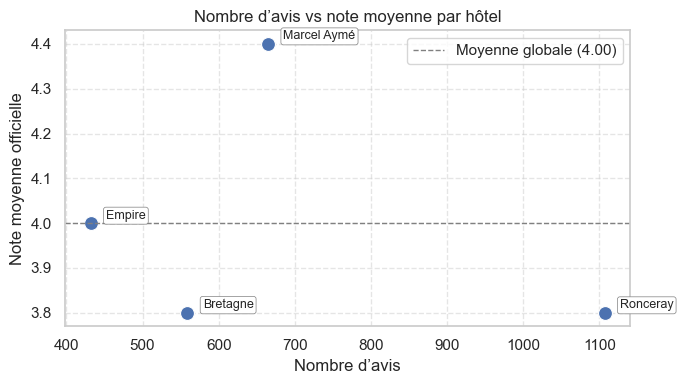

In [10]:
df_plot = df.groupby("hotel")[["note_moyenne"]].first()
df_plot["nb_avis"] = df["hotel"].value_counts()

noms_courts = {
    "BW_Ronceray_Opera": "Ronceray",
    "BW_Bretagne": "Bretagne",
    "BW_Empire_Elysees": "Empire",
    "BW_Litteraire_Marcel_Ayme": "Marcel Aymé",
}
df_plot = df_plot.rename(index=noms_courts)

moyenne_globale = df_plot["note_moyenne"].mean()

plt.figure(figsize=(7, 4))
ax = sns.scatterplot(data=df_plot, x="nb_avis", y="note_moyenne", s=100)
plt.axhline(y=moyenne_globale, color="gray", linestyle="--", linewidth=1,
            label=f"Moyenne globale ({moyenne_globale:.2f})")

for hotel in df_plot.index:
    x, y = df_plot.loc[hotel, "nb_avis"], df_plot.loc[hotel, "note_moyenne"]
    ax.annotate(hotel, (x + 20, y + 0.01), fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.5))

plt.title("Nombre d’avis vs note moyenne par hôtel")
plt.xlabel("Nombre d’avis")
plt.ylabel("Note moyenne officielle")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


L’analyse croisée met en évidence deux profils contrastés : BW Ronceray concentre le plus grand volume d’avis (1107) mais affiche une note moyenne relativement faible (3,8), ce qui suggère une polarisation de l’opinion. À l’inverse, BW Marcel Aymé recueille moins d’avis (665) mais se distingue par la meilleure note moyenne (4,4). Ces différences soulignent que la quantité d’avis ne garantit pas une perception positive : certains hôtels attirent davantage de retours, parfois critiques, alors que d’autres, moins visibles, bénéficient d’une image plus valorisée.

## 📊 5 — Corrélations
- Longueur d’avis ↔ Note  
- Contributions ↔ Note


### Nuage de points : longueur de l’avis vs note


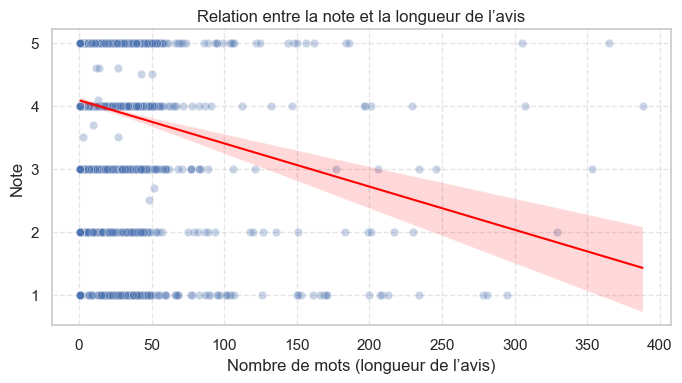

In [11]:
d = df.copy()
d["nb_mots"] = d["avis"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(7, 4))
sns.scatterplot(data=d, x="nb_mots", y="note", alpha=0.3)
sns.regplot(data=d, x="nb_mots", y="note", scatter=False, color="red",
            line_kws={"linewidth": 1.5})
plt.title("Relation entre la note et la longueur de l’avis")
plt.xlabel("Nombre de mots (longueur de l’avis)")
plt.ylabel("Note")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


La relation entre la longueur des avis et la note attribuée montre une tendance nette : plus un avis est long, plus la note tend à baisser. Les avis courts (souvent 4 ou 5 étoiles) traduisent une satisfaction simple et immédiate, alors que les avis détaillés sont fréquemment associés à des expériences négatives ou mitigées. Toutefois, l’impact dépend aussi du contenu : un long commentaire négatif peut peser davantage sur la réputation qu’un bref « super hôtel », ce qui en fait un signal d’influence à surveiller.

### Contributions (tranches) vs note moyenne — points simples


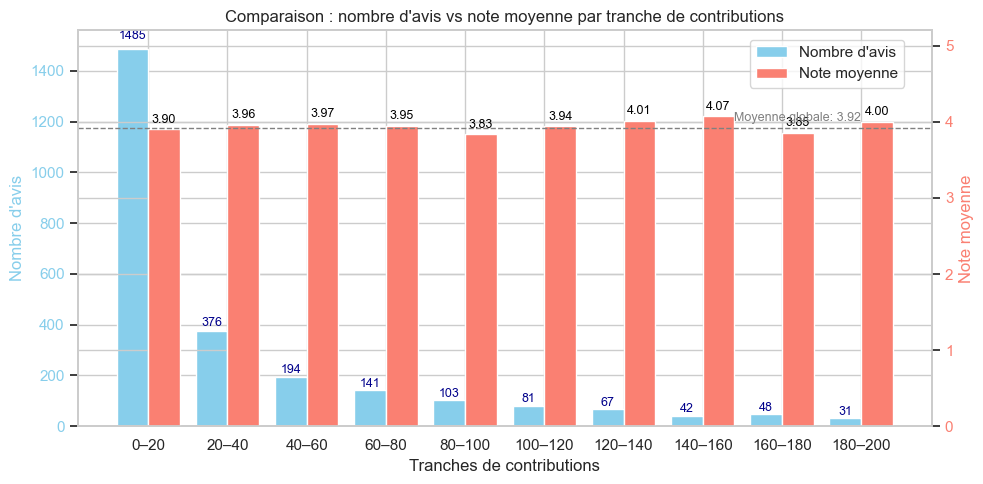

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ========= Préparation des données agrégées =========
d = df.copy()
max_contrib, step = 200, 20
d["contrib_cappe"] = np.minimum(d["contributions"], max_contrib)

edges = np.arange(0, max_contrib + step, step)
d["bin"] = pd.cut(d["contrib_cappe"], bins=edges, right=False)

agg = (
    d.groupby("bin", observed=True)
     .agg(
         note_moy=("note", "mean"),
         count=("note", "size")
     )
     .reset_index()
)

# centre des barres pour l'axe X
agg["x_center"] = agg["bin"].apply(
    lambda b: (b.left + b.right) / 2 if pd.notna(b) else np.nan
)
agg = agg.dropna(subset=["x_center"])

# ========= Tracé côte à côte (deux axes Y) =========
fig, ax1 = plt.subplots(figsize=(10, 5))

bar_width = step * 0.4
x_vals = agg["x_center"].astype(float).values

# Axe gauche : nombre d'avis
bars1 = ax1.bar(
    x_vals - bar_width/2, agg["count"].values,
    width=bar_width, color="skyblue", label="Nombre d'avis"
)
ax1.set_ylabel("Nombre d'avis", color="skyblue")
ax1.tick_params(axis="y", labelcolor="skyblue")

# Valeurs au-dessus (bleu foncé)
for b in bars1:
    h = b.get_height()
    ax1.text(
        b.get_x() + b.get_width()/2, h + max(2, 0.02*h),
        f"{int(h)}", ha="center", va="bottom", color="darkblue", fontsize=9
    )

# Axe droit : note moyenne
ax2 = ax1.twinx()
bars2 = ax2.bar(
    x_vals + bar_width/2, agg["note_moy"].values,
    width=bar_width, color="salmon", label="Note moyenne"
)
ax2.set_ylabel("Note moyenne", color="salmon")
ax2.tick_params(axis="y", labelcolor="salmon")
ax2.set_ylim(0, 5.2)

# Valeurs au-dessus (noir)
for b in bars2:
    h = b.get_height()
    ax2.text(
        b.get_x() + b.get_width()/2, h + 0.05,
        f"{h:.2f}", ha="center", va="bottom", color="black", fontsize=9
    )

# Axe X et labels de tranches
tick_labels = [f"{int(b.left)}–{int(b.right)}" for b in agg["bin"]]
ax1.set_xticks(x_vals)
ax1.set_xticklabels(tick_labels)
ax1.set_xlabel("Tranches de contributions")

# Option : ligne de moyenne globale de la note
mean_note = d["note"].mean()
ax2.axhline(mean_note, linestyle="--", linewidth=1, color="gray")
ax2.text(x_vals[-1], mean_note + 0.05, f"Moyenne globale: {mean_note:.2f}",
         ha="right", va="bottom", color="gray", fontsize=9)

# Légende combinée
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
fig.legend(h1 + h2, l1 + l2, loc="upper right", bbox_to_anchor=(0.92, 0.92))

plt.title("Comparaison : nombre d'avis vs note moyenne par tranche de contributions")
plt.tight_layout()
plt.show()


La comparaison entre le nombre d’avis et la note moyenne par tranche de contributions met en évidence deux constats : la grande majorité des avis provient de contributeurs occasionnels (0–20 contributions), tandis que les plus actifs représentent une minorité mais conservent une note moyenne proche de 4. Autrement dit, les gros contributeurs ne se distinguent pas par une sévérité particulière, mais par leur volume de publications. Leur influence ne repose donc pas uniquement sur la note attribuée, mais sur la visibilité et le contenu de leurs avis, ce qui justifie l’importance d’analyser leur impact textuel par des méthodes de NLP.

In [5]:
from pathlib import Path
import pandas as pd
PROC = Path("../data/processed")

s = pd.read_csv(PROC/"absa_macro_summary_fr.csv")
print("Sommaire macro-thèmes :\n", s)
print("\nSomme des % (doit ≈ 1.0) :", round(s["pct"].sum(), 3))

try:
    counts = pd.read_csv(PROC/"absa_macro_by_hotel_counts_fr.csv")
    meanz  = pd.read_csv(PROC/"absa_macro_by_hotel_mean_fr.csv")
    print("\nCounts (aperçu):\n", counts.head())
    print("\nMean_z (aperçu):\n", meanz.head())
except FileNotFoundError:
    print("\nPas de matrices (colonne 'hotel' manquante au départ?)")

ex = pd.read_csv(PROC/"absa_examples_top_fr.csv")
print("\nExemples (+/-) par thème (aperçu):\n", ex.head(6))


Sommaire macro-thèmes :
                  macro_topic    n    mean_z  pct_influents       pct
0          Accueil / Service  470  0.660638       0.121277  0.242143
1          Chambre / Confort  436  0.175459       0.071101  0.224626
2  Localisation / Transports  427  0.638173       0.070258  0.219990
3             Petit-déjeuner  262  0.431298       0.064885  0.134982
4              Salle de bain  147  0.224490       0.156463  0.075734
5                   Propreté  112  0.633929       0.062500  0.057702
6       Rapport qualité-prix   87  0.477011       0.344828  0.044822

Somme des % (doit ≈ 1.0) : 1.0

Counts (aperçu):
                        hotel  Accueil / Service  Chambre / Confort  \
0                BW_Bretagne                 97                 86   
1          BW_Empire_Elysees                 65                 49   
2  BW_Litteraire_Marcel_Ayme                184                116   
3          BW_Ronceray_Opera                124                185   

   Localisation / Tra